![cyber_photo](cyber_photo.jpg)




### The Data

| Column     | Description              |
|------------|--------------------------|
|`processId`|The unique identifier for the process that generated the event - int64 |
|`threadId`|ID for the thread spawning the log - int64|
|`parentProcessId`|Label for the process spawning this log - int64|
|`userId`|ID of user spawning the log|Numerical - int64|
|`mountNamespace`|Mounting restrictions the process log works within - int64|
|`argsNum`|Number of arguments passed to the event - int64|
|`returnValue`|Value returned from the event log (usually 0) - int64|
|`sus_label`|Binary label as suspicous event (1 is suspicious, 0 is not) - int64|

More information on the dataset: [BETH dataset](accreditation.md)

In [47]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torchmetrics import Accuracy
from tqdm import tqdm
# from sklearn.metrics import accuracy_score  # uncomment to use sklearn

In [48]:
# Load preprocessed data
train_df = pd.read_csv('labelled_train.csv')
test_df = pd.read_csv('labelled_test.csv')
val_df = pd.read_csv('labelled_validation.csv')

# View the first 5 rows of training set
train_df.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue,sus_label
0,381,7337,1,100,4026532231,5,0,1
1,381,7337,1,100,4026532231,1,0,1
2,381,7337,1,100,4026532231,0,0,1
3,7347,7347,7341,0,4026531840,2,-2,1
4,7347,7347,7341,0,4026531840,4,0,1


In [49]:
#extract the datasets
X_train = train_df.iloc[:, :-1]
Y_train = train_df.iloc[:, 7]
X_val = val_df.iloc[:, :-1]
Y_val = val_df.iloc[:, 7]
X_test = test_df.iloc[:, :-1]
Y_test = test_df.iloc[:, 7]

<h1> Data Visualization </h1>

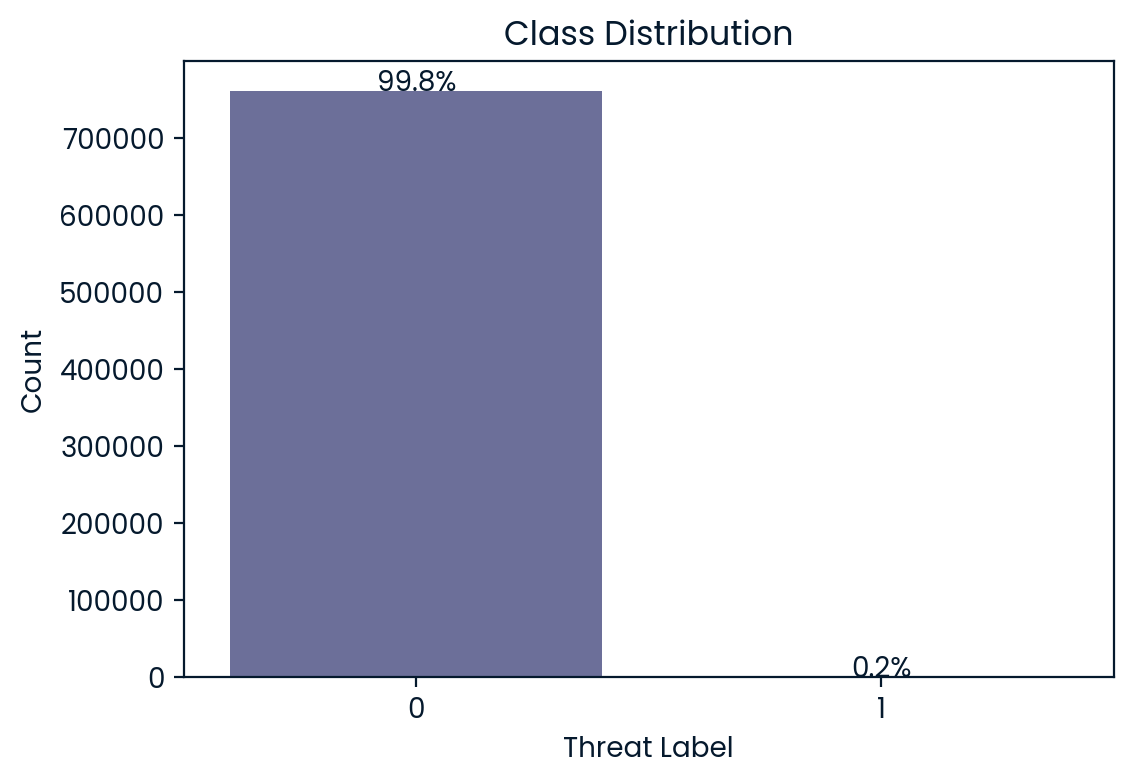

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.countplot(x='sus_label', data=train_df)
plt.title("Class Distribution")
plt.xlabel("Threat Label")
plt.ylabel("Count")
total = len(train_df)
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2, height + 1, f'{height/total*100:.1f}%', 
             ha='center')
plt.show()


Imbalanced dataset, will have to look at confusion matrix after classification for more insights

 0       526690
 9       106839
 6        31310
 15       23848
-2        20207
          ...  
 7478         1
 7479         1
 7480         1
 7481         1
 7673         1
Name: returnValue, Length: 524, dtype: int64


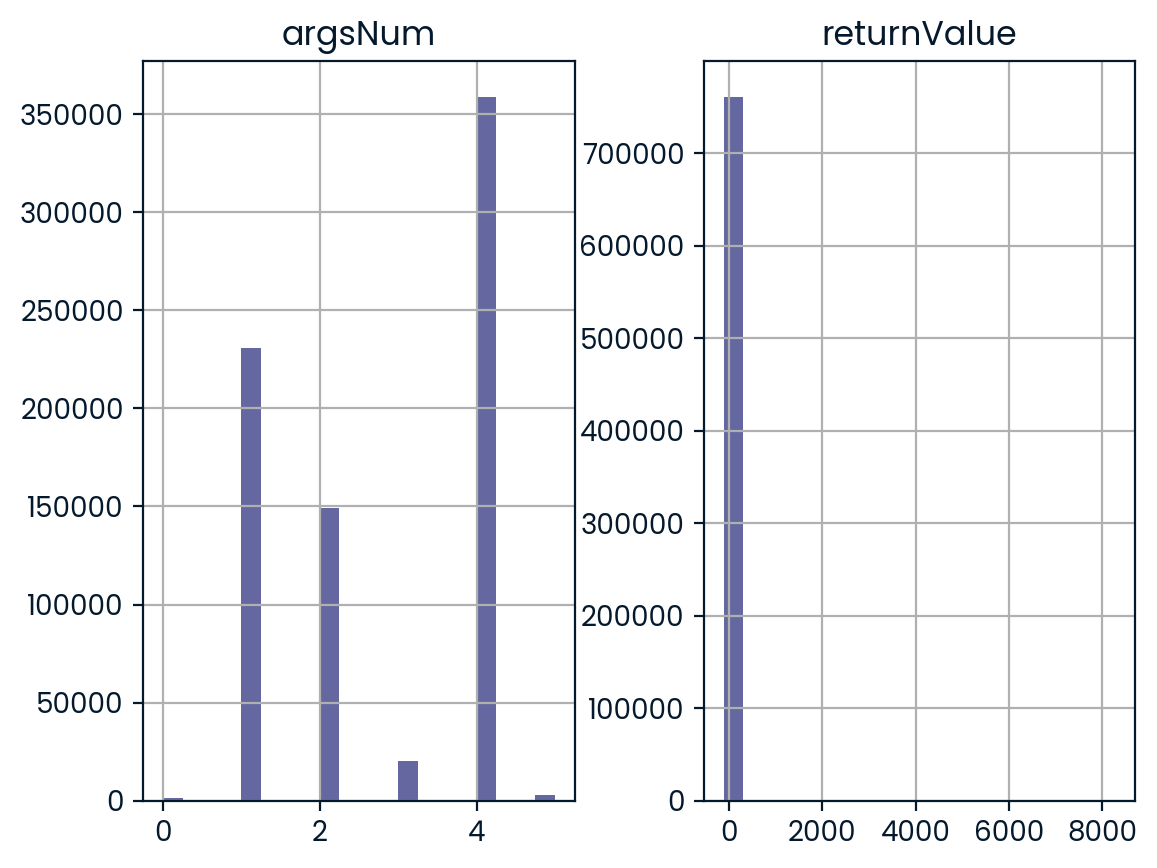

In [51]:
X_train[['argsNum', 'returnValue']].hist(bins = 20)
print(X_train['returnValue'].value_counts())
plt.show()

Even though the graphs show that the distrubution is skewed, printing the results shows that the number of smaller class samples are not that few to remove from the dataset, so we'll continue

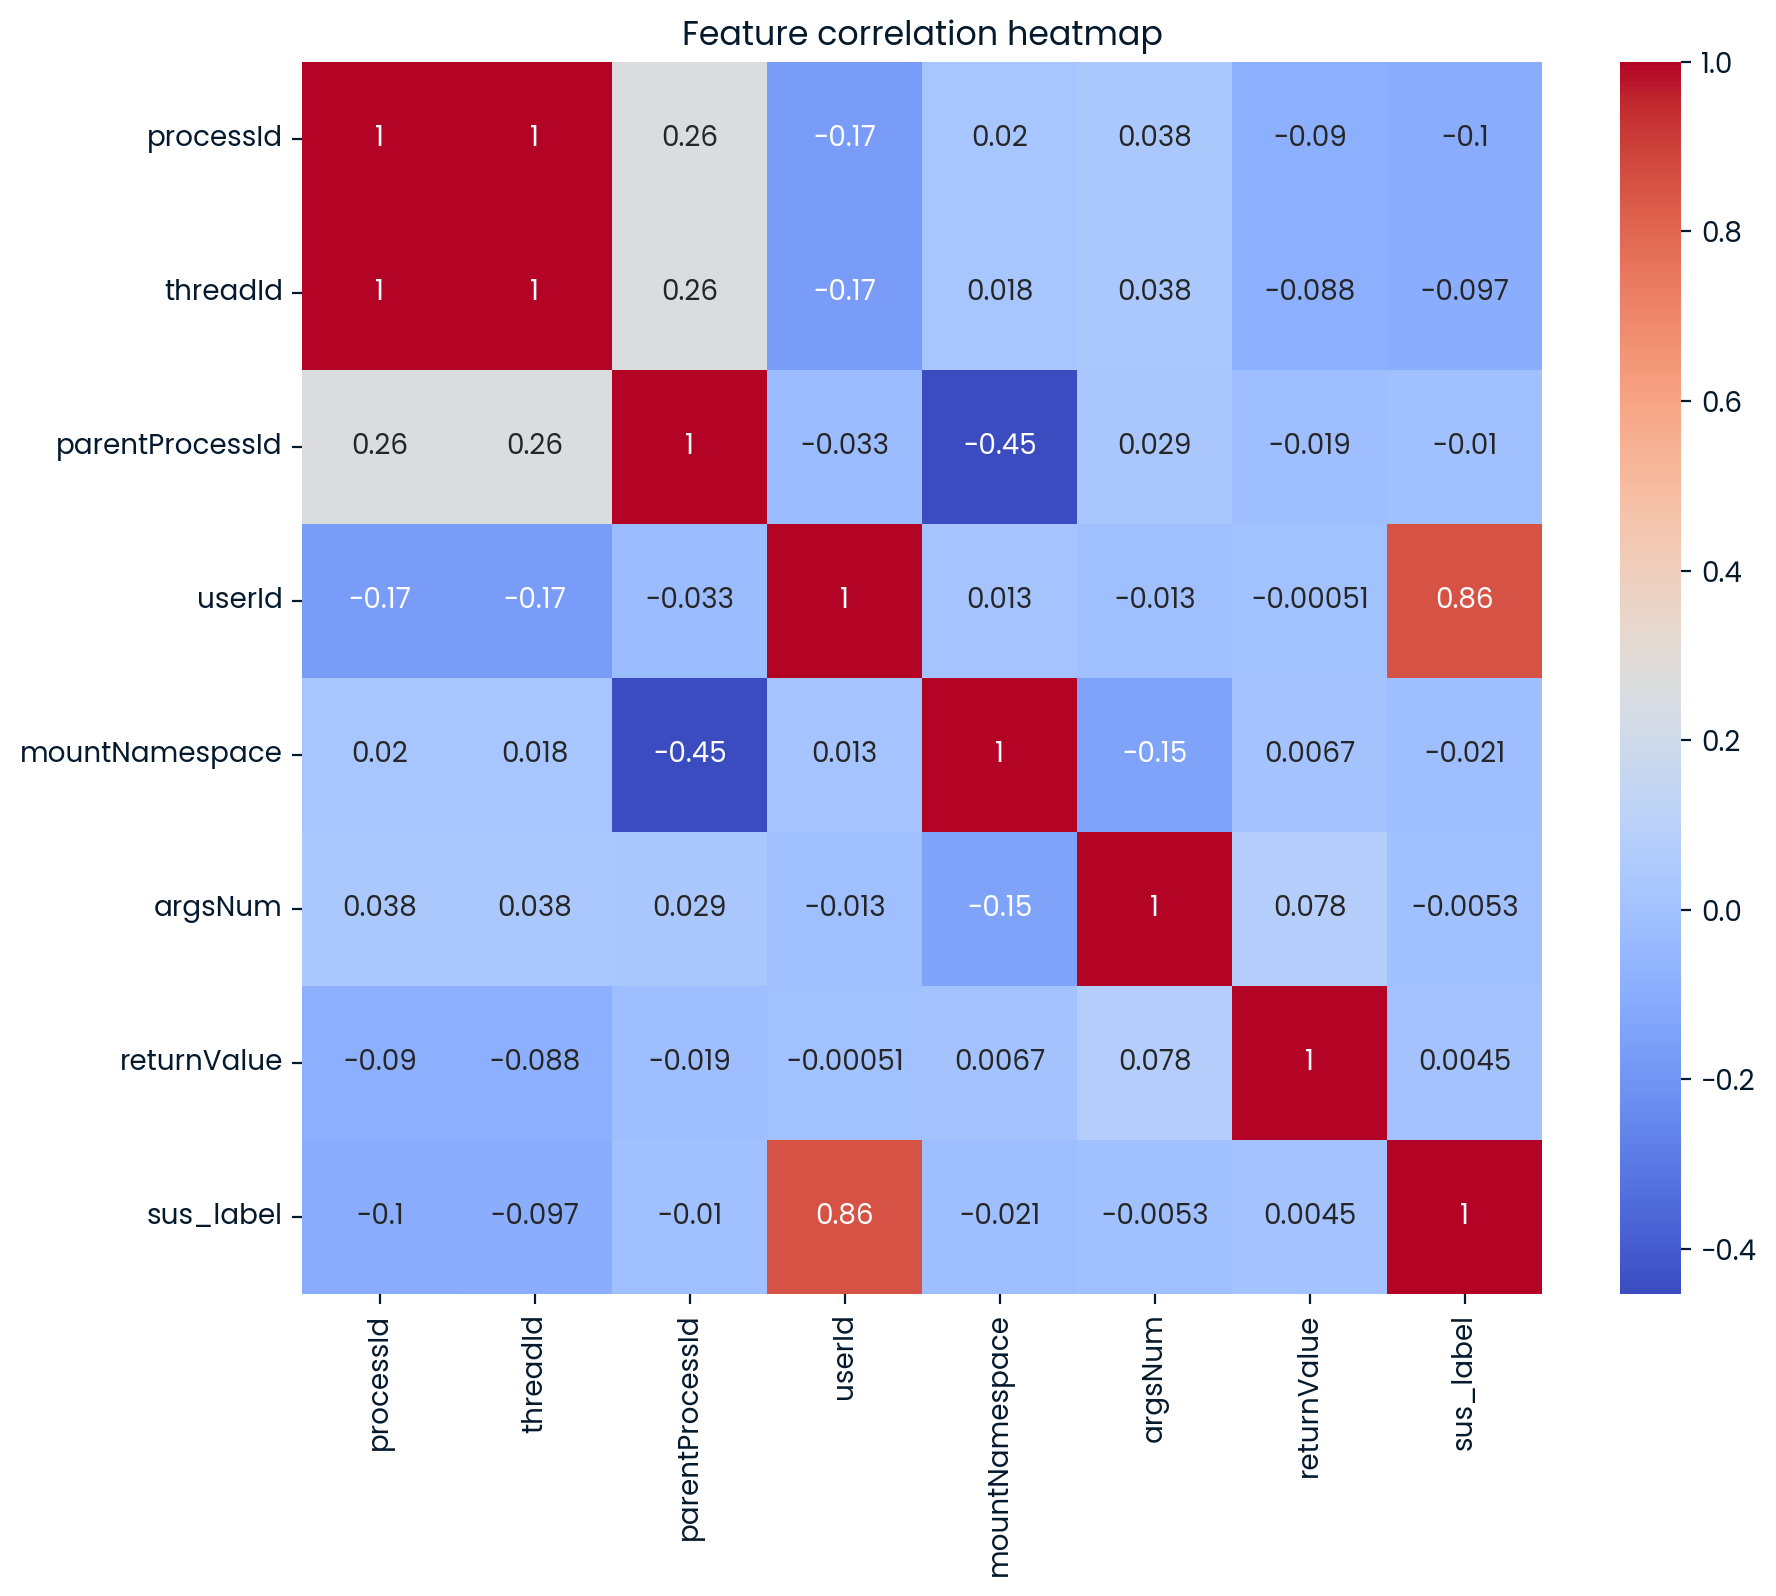

In [52]:
plt.figure(figsize = (10, 8))

sns.heatmap(train_df.corr(), annot = True, cmap = 'coolwarm')
plt.title("Feature correlation heatmap")
plt.show()

removing thread id low correlation with target and has high correlation with processid. reducing multicollinearity

In [53]:
X_train.head()

,processId,threadId,parentProcessId,userId,mountNamespace,argsNum,returnValue
0,381,7337,1,100,4026532231,5,0
1,381,7337,1,100,4026532231,1,0
2,381,7337,1,100,4026532231,0,0
3,7347,7347,7341,0,4026531840,2,-2
4,7347,7347,7341,0,4026531840,4,0


<h1>Model Training</h1>

In [54]:



#scaler
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_val = scalar.transform(X_val)
X_test = scalar.transform(X_test)
#convert to tensor
X_train = torch.tensor(X_train, dtype = torch.float32)
Y_train = torch.tensor(Y_train.values, dtype = torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype = torch.float32)
Y_val = torch.tensor(Y_val.values, dtype = torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype = torch.float32)
Y_test = torch.tensor(Y_test.values, dtype = torch.float32).view(-1, 1)

#dataloaders
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size = 128, shuffle = True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size = 128, shuffle = True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size = 128, shuffle = True)

inp_shape = X_train.size()[1]


In [32]:
from torchmetrics import Accuracy, F1Score, Recall, Precision
#define the model
model = nn.Sequential(
    nn.Linear(inp_shape, 128),
    nn.ReLU(),
    nn.Linear(128, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)
#weighted loss
num_pos = (Y_train == 1).sum().item()
num_neg = (Y_train == 0).sum().item()

#weight for positive class
pos_weight = torch.tensor(num_neg / num_pos, dtype = torch.float32)

criterion = nn.BCELoss()
optimizer = optim.Adam(params = model.parameters(), lr = 0.001)

n_epochs = 10

accuracy = Accuracy(task="binary")
f1score = F1Score(task="binary")
recall = Recall (task="binary")
precision = Precision(task="binary")

#loss arrays
train_loss_arr = []
val_loss_arr = []
train_acc_arr = []
val_acc_arr = []

for epoch in range(n_epochs + 1):
    #training
    model.train()
    train_loss = 0.0

    for X_batch, Y_batch in tqdm(train_loader):
        optimizer.zero_grad()
        sample_weights = torch.where(Y_batch == 1, pos_weight, 1.0)
        y_pred = model(X_batch)
        loss = nn.BCELoss(weight=sample_weights)(y_pred, Y_batch)
        loss.backward()
        optimizer.step()
        #update train_loss
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_loss_arr.append(train_loss)
    train_pred = (model(X_train) > 0.5).float()
    acc_train = accuracy(train_pred, Y_train)
    train_acc_arr.append(acc_train)

    #validation
    model.eval()
    val_loss = 0.0
    accuracy.reset()

    with torch.no_grad():
        for X_batch, Y_batch in tqdm(val_loader):
            y_pred = model(X_batch)
            loss = criterion(y_pred, Y_batch)
            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_pred = (model(X_val)>0.5).float()
        acc_val = accuracy(val_pred, Y_val)
        f1_score = f1score(val_pred, Y_val)
        rec = recall(val_pred, Y_val)
        pre = precision(val_pred, Y_val)
        val_loss_arr.append(val_loss)
        val_acc_arr.append(acc_val)
        accuracy.reset()
        


    print(f'Epoch {epoch} Train Loss {train_loss:.3f} Val loss {val_loss:.3f} Val acc {acc_val:.3f} Precision  {pre:.3f}  Recall {rec:.3f} F1 {f1_score:.3f}')


    

100%|██████████| 1477/1477 [00:06<00:00, 227.55it/s]


Epoch 0 Train Loss 0.441 Val loss 0.001 Val acc 1.000 Precision  0.996  Recall 0.989 F1 0.992


100%|██████████| 1477/1477 [00:06<00:00, 239.13it/s]


In [33]:
model.eval()

with torch.no_grad():
    y_predict_train = model(X_train)
    y_predict_test = model(X_test)
    y_predict_val  = model(X_val)

In [34]:
train_accuracy = accuracy(y_predict_train, Y_train).item()
val_accuracy = accuracy(y_predict_val, Y_val).item()
test_accuracy  = accuracy(y_predict_test, Y_test).item()

print(f'Train acc {train_accuracy}')
print(f'Val acc {val_accuracy}')
print(f'Test acc {test_accuracy}')

Train acc 0.9636621475219727
Val acc 0.9969465732574463
Test acc 0.9678356647491455


# Classification plots Plots

In this section, we will visualize the training, validation, and test accuracies to better understand the model's performance across different data splits.

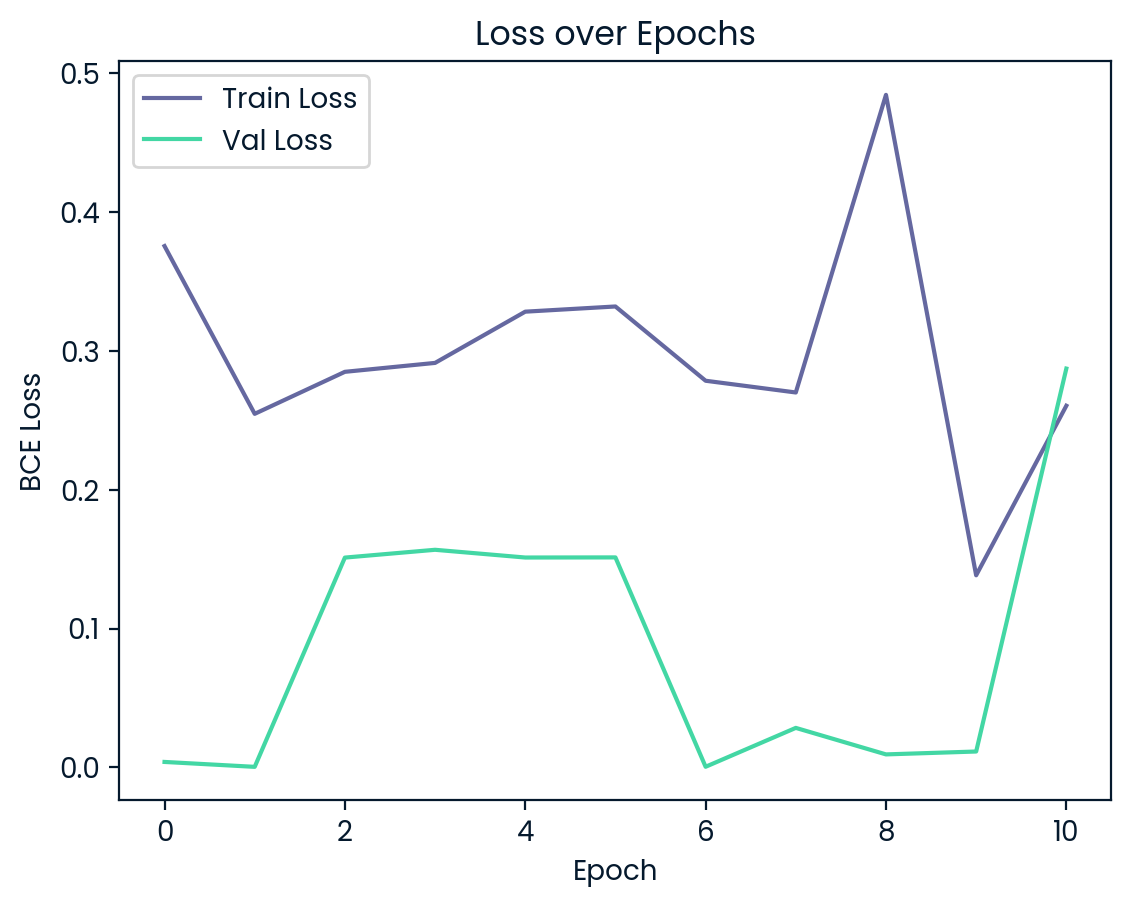

In [35]:
plt.plot(train_loss_arr, label = 'Train Loss')
plt.plot(val_loss_arr, label = 'Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel("BCE Loss")
plt.legend()
plt.show()

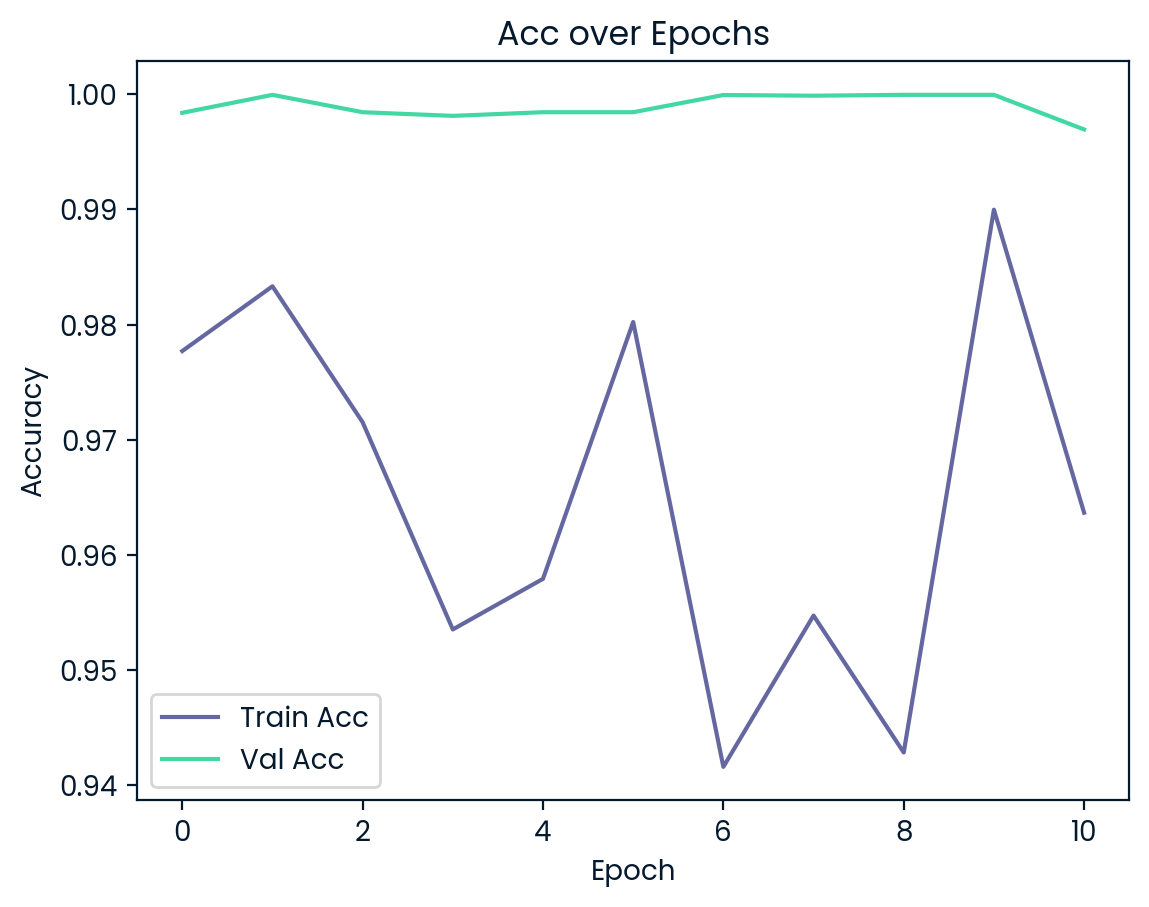

In [46]:
plt.plot(train_acc_arr, label = 'Train Acc')
plt.plot(val_acc_arr, label = 'Val Acc')
plt.title('Acc over Epochs')
plt.xlabel('Epoch')
plt.ylabel("Accuracy")
plt.legend()
plt.show()

High accuracy was observed for all the epochs. Which means that weighted loss worked. Training accuracy fluctuated but not my a significant margin and the best weights had a high training and validation accuracies. Validationa and test accuracy remains high which shows model generalizes well to unseen data

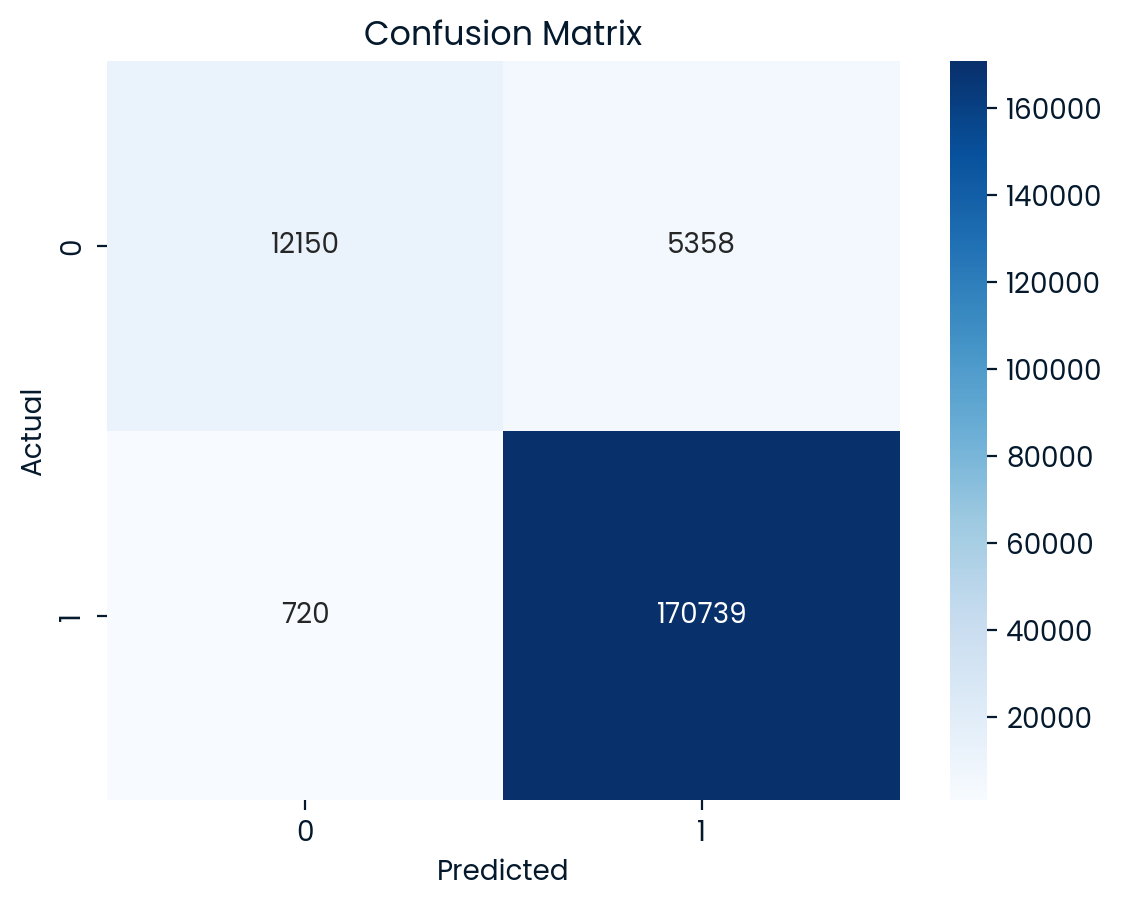

In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, (y_predict_test.detach().numpy()>0.5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

From the confusion matrix it's evident the number of misclassifications is significantly less as compared to the correct classifications for both the classes.

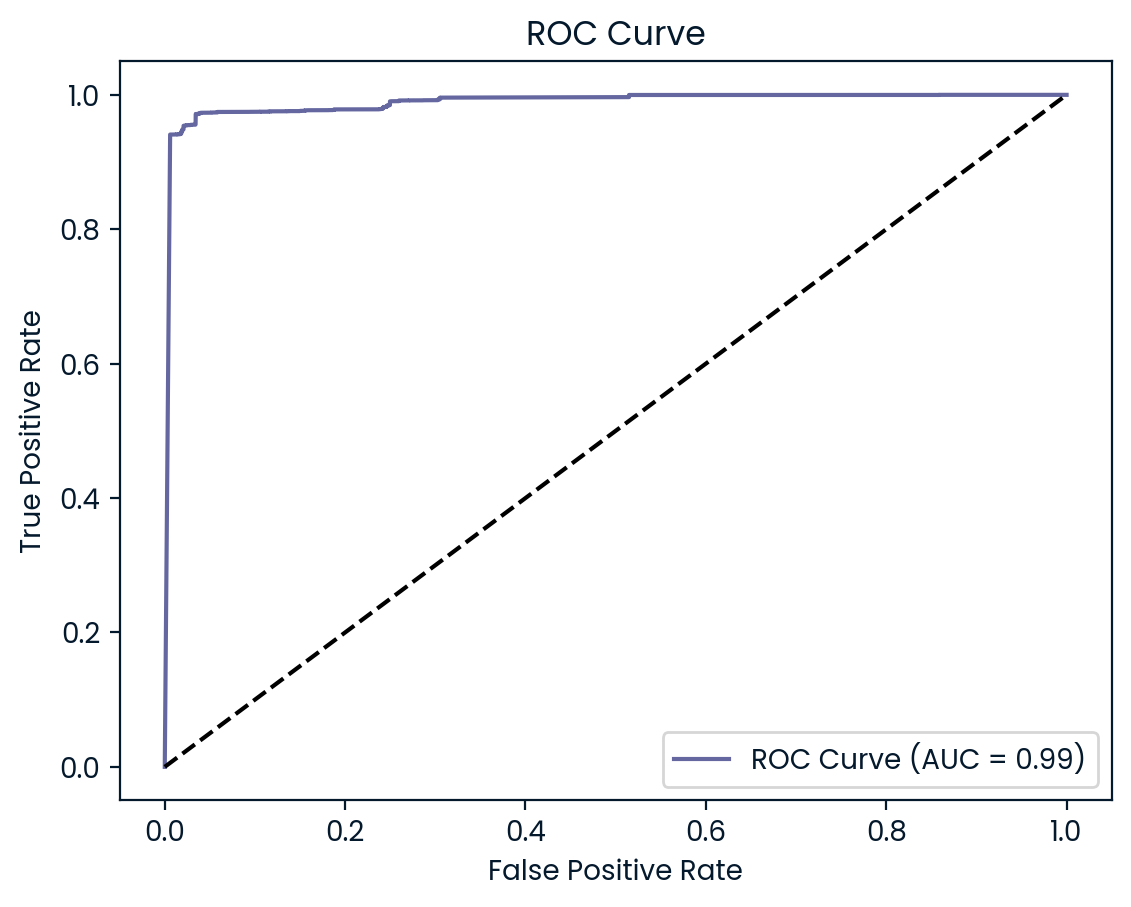

In [44]:
from sklearn.metrics import roc_curve,auc
fpr, tpr, _ = roc_curve(Y_test,( y_predict_test.detach().numpy()))
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label = f'ROC Curve (AUC = {roc_auc :.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

AUC of 0.99 shows excellent classification performance. Model can perfectly distinguish between normal (0) and sus (1) samples.
<ul>
    <li>We have high tpr rate. The model correctly identifies most suspicious samples</li>
<li>We have los false positive rate. Very few normal samples are incorrectly flagged as suspicious.</li> 
</ul> 

Model achieves a good balance between detecting threats and minimizing false alarms.